# Corporate Signal Intelligence
## Notebook 02: Data Analysis, Cleansing & Quality Assurance

This notebook turns the raw collection into the validated analytical base that every
later stage depends on. It is deliberately more than a type-casting exercise: the
quality of an unsupervised anomaly detector cannot be judged by a labelled test set,
so the credibility of the result rests on the credibility of the input. Everything
downstream inherits the decisions made here, and each one is stated explicitly.

### Universe and sources

| Layer | Source | Grain | Purpose |
|---|---|---|---|
| Market | Stooq daily OHLCV | ticker × trading day | price and volume behaviour |
| Disclosure | SEC EDGAR submissions | ticker × filing | corporate event activity |
| Fundamentals | SEC EDGAR XBRL company facts | ticker × concept × period | financial context |

The universe is ten large US technology issuers: AAPL, MSFT, NVDA, GOOGL, AMZN, META,
TSLA, AMD, INTC and ORCL. The selection is deliberately homogeneous, a common sector
and a common exchange calendar mean that a day flagged as atypical is atypical relative
to a comparable peer set, not relative to an artificial mix of business models.

### Quality dimensions assessed

The assessment follows the classic data-quality dimensions, each one made computable
rather than asserted:

| Dimension | Question | How it is measured here |
|---|---|---|
| **Completeness** | Are required fields populated? | missing-value rate on required columns |
| **Uniqueness** | Is each real-world event represented once? | duplicate rate on the natural key |
| **Validity** | Do values obey domain rules? | OHLC ordering, non-negative volume, date ordering |
| **Consistency** | Do the sources agree with each other? | filings reconciled against the trading calendar |
| **Timeliness** | Is the data current relative to collection? | lag between last observation and collection timestamp |
| **Lineage** | Does the record belong to the entity we think it does? | CIK-to-ticker mapping across corporate reorganisations |

### What changed relative to the first version of this notebook

1. **The 2015 cut-off was removed.** The original pipeline discarded everything before
   2015-01-01, keeping roughly eleven years. The market series actually reach back to
   1972 and the EDGAR electronic archive to 1994, which restores several complete market
   regimes, the dot-com collapse, the 2008 financial crisis, the COVID shock, that a
   model trained on a single bull-market regime never sees.
2. **Corporate lineage is now resolved.** Filings were previously collected under the
   current CIK only, which silently truncated two histories. Section 2 documents the
   problem and the fix.
3. **Quality is measured, not assumed.** The notebook ends with a reproducible scorecard
   written to disk rather than a narrative claim that the data is clean.

In [1]:
# Dependencies for the analysis and cleansing stage

%pip install -q pandas numpy scipy matplotlib seaborn missingno pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment, project style and configuration

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

sys.path.append("notebooks")
import csi_viz as viz

warnings.filterwarnings("ignore")
viz.apply_style()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_DIR = Path("data")

UNIVERSE = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN",
    "META", "TSLA", "AMD", "INTC", "ORCL",
]

# EDGAR renamed several forms over the years without changing what they disclose.
# 10-K405 (1996-2002) is an annual report; 8-K12B/8-K12G3 are current reports tied to
# a registration event. Mapping them onto a stable family keeps a thirty-year series
# comparable instead of showing a phantom collapse in annual filings before 2003.
FORM_FAMILY = {
    "10-K": "10-K", "10-K405": "10-K", "10-KSB": "10-K",
    "10-Q": "10-Q", "10-QSB": "10-Q",
    "8-K": "8-K", "8-K12B": "8-K", "8-K12G3": "8-K",
}

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "| numpy:", np.__version__)

Python: 3.14.6
pandas: 3.0.5 | numpy: 2.4.6


---

## 1. Raw data inventory

Before any transformation, each raw dataset is described on its own terms: how many
records it holds, what period it covers and how much of the universe it reaches. This
is the baseline against which every later cleaning decision is measured.

In [3]:
# Loading the raw collected datasets

market_raw_df = pd.read_csv(DATA_DIR / "stooq_market_raw.csv", parse_dates=["date"])
companies_raw_df = pd.read_csv(DATA_DIR / "sec_companies_selected.csv")
filings_raw_df = pd.read_csv(
    DATA_DIR / "sec_filings_full_raw.csv",
    parse_dates=["filing_date", "report_date"],
)
facts_raw_df = pd.read_csv(
    DATA_DIR / "sec_company_facts_full_raw.csv",
    parse_dates=["start_date", "end_date", "filing_date"],
)

for frame in (market_raw_df, filings_raw_df, facts_raw_df):
    frame["collected_at"] = pd.to_datetime(frame["collected_at"], utc=True)

raw_datasets = {
    "market (Stooq OHLCV)": (market_raw_df, "date"),
    "filings (EDGAR submissions)": (filings_raw_df, "filing_date"),
    "facts (EDGAR XBRL)": (facts_raw_df, "end_date"),
}

inventory_rows = []
for name, (frame, date_column) in raw_datasets.items():
    inventory_rows.append({
        "dataset": name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "memory_mb": round(frame.memory_usage(deep=True).sum() / 1e6, 1),
        "tickers": frame["ticker"].nunique(),
        "first_observation": frame[date_column].min().date(),
        "last_observation": frame[date_column].max().date(),
        "collected_at": frame["collected_at"].max().date(),
    })

raw_inventory_df = pd.DataFrame(inventory_rows)
raw_inventory_df

,dataset,rows,columns,memory_mb,tickers,first_observation,last_observation,collected_at
0,market (Stooq OHLCV),81996,9,6.6000,10,1972-01-07,2026-05-21,2026-05-21
1,filings (EDGAR submissions),37384,10,5.7000,10,1994-01-11,2026-08-06,2026-08-07
2,facts (EDGAR XBRL),15495,17,9.2000,10,2006-09-30,2026-06-30,2026-08-07


In [4]:
# Per-ticker coverage across the three sources

def coverage_span(frame: pd.DataFrame, date_column: str, prefix: str) -> pd.DataFrame:
    grouped = frame.groupby("ticker")[date_column].agg(["count", "min", "max"])
    grouped.columns = [f"{prefix}_rows", f"{prefix}_start", f"{prefix}_end"]
    return grouped

core_forms_mask = filings_raw_df["form_type"].isin(FORM_FAMILY)

coverage_df = (
    coverage_span(market_raw_df, "date", "market").join(coverage_span(filings_raw_df[core_forms_mask], "filing_date", "filings")).join(coverage_span(facts_raw_df, "filing_date", "facts")).reindex(UNIVERSE)
)

coverage_df["market_years"] = (
    (coverage_df["market_end"] - coverage_df["market_start"]).dt.days / 365.25
).round(1)

coverage_df[[
    "market_rows", "market_start", "market_end", "market_years",
    "filings_rows", "filings_start", "facts_rows", "facts_start",
]]

,market_rows,market_start,market_end,market_years,filings_rows,filings_start,facts_rows,facts_start
ticker,,,,,,,,
AAPL,10507,1984-09-07,2026-05-21,41.7000,363,1994-01-26,1716,2009-07-22
MSFT,10124,1986-03-13,2026-05-21,40.2000,411,1994-02-14,1768,2009-10-23
NVDA,6874,1999-01-22,2026-05-21,27.3000,350,1999-04-29,1735,2009-08-20
GOOGL,5474,2004-08-19,2026-05-21,21.8000,339,2004-07-09,1594,2009-08-04
AMZN,7294,1997-05-16,2026-05-21,29.0000,384,1997-08-14,1506,2009-07-24
META,3522,2012-05-18,2026-05-21,14.0000,188,2012-06-25,1375,2012-07-31
TSLA,3999,2010-06-28,2026-05-21,15.9000,309,2010-08-04,1644,2011-08-12
AMD,10878,1983-03-21,2026-05-21,43.2000,552,1994-01-27,1478,2010-08-04
INTC,13697,1972-01-07,2026-05-21,54.4000,575,1994-03-25,1344,2009-08-03


Three structural facts follow from the coverage table, and each one constrains the
modelling that comes later.

**History lengths differ by design, not by defect.** Intel's series starts in 1972 and
Tesla's in 2010 because that is when each company began trading. The panel is therefore
unbalanced, and any statistic computed by pooling raw rows across tickers is implicitly
weighted toward the older issuers. Per-ticker normalisation in the feature stage is what
neutralises this.

**The disclosure series cannot start before EDGAR.** Electronic filing was phased in
between 1993 and 1996, so filing-activity features are only meaningful from 1994 onward
regardless of how far back the price series reaches.

**Fundamentals start in 2009.** XBRL tagging became mandatory for large filers in phases
beginning mid-2009, so the financial-concept layer has a hard left boundary that the
other two layers do not share. This is the single most important constraint on the
modelling window and it is revisited in the feature-engineering notebook.

---

## 2. Corporate lineage: a ticker is not an entity

The first collection retrieved filings by the issuer's *current* CIK. That is the
obvious approach and it is quietly wrong for any company that has reorganised, because
EDGAR keys filings to the legal entity that filed them, not to the ticker that trades
today.

Two of the ten issuers are affected:

| Ticker | Current entity | Predecessor entity | History lost by using the current CIK alone |
|---|---|---|---|
| GOOGL | Alphabet Inc. (CIK 1652044, from Oct 2015) | Google Inc. (CIK 1288776) | 2004–2015, including the IPO year |
| ORCL | Oracle Corporation (CIK 1341439, from Oct 2005) | Oracle Systems Corp. (CIK 777676) | 1994–2005 |

The collection script `scripts/collect_sec_full_history.py` resolves this by treating a
ticker as a *sequence* of legal entities. Because a predecessor keeps filing after the
successor appears, Google Inc. still files as an Alphabet subsidiary, each predecessor
is bounded by an explicit validity window that ends at the successor's first filing, and
the union is deduplicated on accession number.

The same script also fixes a second, subtler truncation: the EDGAR submissions endpoint
returns only the most recent ~1,000 filings inline and pushes the remainder into
paginated archive documents. A collector that reads only the inline block silently loses
the deep history of any company that files frequently.

In [5]:
# Filing composition by legal entity

lineage_df = (
    filings_raw_df.groupby(["ticker", "entity_name", "cik"]).agg(
        filings=("accession_number", "size"),
        first_filing=("filing_date", "min"),
        last_filing=("filing_date", "max"),
    ).reset_index().sort_values(["ticker", "first_filing"])
)

lineage_df["is_predecessor"] = lineage_df.duplicated("ticker", keep="last")
lineage_df

,ticker,entity_name,cik,filings,first_filing,last_filing,is_predecessor
0,AAPL,Apple Inc.,320193,2238,1994-01-26,2026-07-31,False
1,AMD,"Advanced Micro Devices, Inc.",2488,3277,1994-01-27,2026-08-05,False
2,AMZN,"Amazon.com, Inc.",1018724,3097,1997-03-24,2026-08-06,False
4,GOOGL,Google Inc.,1288776,6370,2001-03-12,2015-10-01,True
3,GOOGL,Alphabet Inc.,1652044,2676,2015-10-02,2026-08-06,False
5,INTC,Intel Corporation,50863,3967,1994-02-10,2026-08-03,False
6,META,"Meta Platforms, Inc.",1326801,4158,2005-05-06,2026-08-06,False
7,MSFT,Microsoft Corporation,789019,4481,1994-02-14,2026-08-06,False
8,NVDA,NVIDIA Corporation,1045810,2461,1998-03-06,2026-07-20,False
10,ORCL,Oracle Systems Corporation,777676,602,1994-01-11,2005-10-13,True


---

## 3. Market data integrity

Daily OHLCV data obeys arithmetic rules that hold regardless of what the market did. A
high below the low, a close outside the day's range, a negative volume or two rows for
the same session are impossible in reality, so each occurrence is a defect in the feed
rather than an unusual trading day. Testing for them explicitly separates *data* problems
from the *market* anomalies the project is actually looking for, a distinction that
matters enormously for an anomaly detector, which would otherwise learn to flag the
vendor's mistakes.

In [6]:
# Domain rules that daily OHLCV must satisfy

market_raw_df = market_raw_df.sort_values(["ticker", "date"]).reset_index(drop=True)

intraday_high = market_raw_df[["open", "close"]].max(axis=1)
intraday_low = market_raw_df[["open", "close"]].min(axis=1)

integrity_rules = {
    "non-positive close": market_raw_df["close"] <= 0,
    "non-positive open": market_raw_df["open"] <= 0,
    "high below low": market_raw_df["high"] < market_raw_df["low"],
    "high below open/close": market_raw_df["high"] < intraday_high,
    "low above open/close": market_raw_df["low"] > intraday_low,
    "negative volume": market_raw_df["volume"] < 0,
    "zero volume": market_raw_df["volume"] == 0,
    "duplicated ticker-date": market_raw_df.duplicated(["ticker", "date"]),
    "missing values in row": market_raw_df.isna().any(axis=1),
}

integrity_df = pd.DataFrame([
    {
        "rule": rule,
        "violations": int(mask.sum()),
        "share_pct": round(100 * mask.mean(), 4),
    }
    for rule, mask in integrity_rules.items()
])

integrity_df

,rule,violations,share_pct
0,non-positive close,0,0.0000
1,non-positive open,0,0.0000
2,high below low,0,0.0000
3,high below open/close,0,0.0000
4,low above open/close,0,0.0000
5,negative volume,0,0.0000
6,zero volume,8,0.0098
7,duplicated ticker-date,0,0.0000
8,missing values in row,0,0.0000


In [7]:
# Inspecting the only rule with violations

zero_volume_df = market_raw_df.loc[
    market_raw_df["volume"] == 0,
    ["ticker", "date", "open", "high", "low", "close", "volume"],
]

zero_volume_df

,ticker,date,open,high,low,close,volume
17341,AMD,2010-04-26,9.8200,10.1500,9.7100,9.9700,0.0000
24635,AMZN,2010-04-26,7.1600,7.3860,7.1455,7.3555,0.0000
30171,GOOGL,2010-07-23,11.9756,12.2207,11.9676,12.2073,0.0000
43806,INTC,2010-04-26,15.9666,16.0077,15.7987,15.7987,0.0000
57452,MSFT,2010-04-26,23.8264,24.0341,23.7224,23.9088,0.0000
64326,NVDA,2010-04-26,0.3774,0.3851,0.3767,0.3806,0.0000
73953,ORCL,2010-04-26,22.4190,22.5081,22.2119,22.4031,0.0000
77997,TSLA,2010-06-28,1.1333,1.1333,1.1333,1.1333,0.0000


The arithmetic rules hold everywhere except for volume. Eight sessions report zero
shares traded, and the pattern gives the cause away: seven of the eight fall on
**2010-04-26**, across seven unrelated issuers, with entirely normal prices on the same
rows. Seven mega-cap stocks did not simultaneously stop trading on an ordinary Monday,
this is a vendor artefact in the volume field, not a market event.

Tesla's row is different in kind: 2010-06-28 is its first trading session, where a zero
carries no information either.

The treatment follows from the diagnosis. The prices on those rows are valid and are
kept; only the volume field is unreliable, so it is set to missing and interpolated
within the ticker, with a flag preserved so that any later analysis can exclude the
imputed points. Deleting the rows would punch holes in the return series for no reason;
leaving the zeros would inject artificial volume collapses of exactly the kind the
anomaly model is meant to detect.

In [8]:
# Trading-calendar continuity

calendar_df = market_raw_df.copy()
calendar_df["gap_days"] = calendar_df.groupby("ticker")["date"].diff().dt.days

gap_summary_df = (
    calendar_df.groupby("ticker")["gap_days"].agg(
        median_gap="median",
        max_gap="max",
        gaps_over_5_days=lambda values: int((values > 5).sum()),
        gaps_over_10_days=lambda values: int((values > 10).sum()),
    ).reindex(UNIVERSE)
)

gap_summary_df

,median_gap,max_gap,gaps_over_5_days,gaps_over_10_days
ticker,,,,
AAPL,1.0000,7.0000,1,0
MSFT,1.0000,7.0000,1,0
NVDA,1.0000,7.0000,1,0
GOOGL,1.0000,5.0000,0,0
AMZN,1.0000,7.0000,1,0
META,1.0000,5.0000,0,0
TSLA,1.0000,5.0000,0,0
AMD,1.0000,7.0000,1,0
INTC,1.0000,7.0000,3,0


No ticker shows a single gap longer than five calendar days. The maximum observed gaps
are the ordinary long weekends of the US exchange calendar, so the series contain no
missing trading sessions that would need to be reconstructed: a meaningful result,
because a silently missing week would distort every rolling window computed later.

In [9]:
# Extreme single-day moves: split artefacts or real events?

returns_df = market_raw_df.copy()
returns_df["log_return"] = np.log(
    returns_df["close"] / returns_df.groupby("ticker")["close"].shift(1)
)

extreme_moves_df = (
    returns_df.loc[returns_df["log_return"].abs() > 0.35,
                   ["ticker", "date", "close", "volume", "log_return"]].sort_values("date").reset_index(drop=True)
)

# Only well-documented market-wide or company-defining events are pre-labelled. The
# remainder stay explicitly unlabelled rather than being attributed to a guessed cause.
DOCUMENTED_EVENTS = {
    ("AMD", "1987-10-19"): "Black Monday, global equity crash",
    ("MSFT", "1987-10-19"): "Black Monday, global equity crash",
    ("AAPL", "2000-09-29"): "Q4 FY2000 earnings warning",
}

extreme_moves_df["documented_event"] = [
    DOCUMENTED_EVENTS.get((row.ticker, row.date.strftime("%Y-%m-%d")), "unlabelled")
    for row in extreme_moves_df.itertuples()
]

extreme_moves_df["move_pct"] = (np.expm1(extreme_moves_df["log_return"]) * 100).round(1)
extreme_moves_df[["ticker", "date", "close", "move_pct", "documented_event"]]

,ticker,date,close,move_pct,documented_event
0,INTC,1972-01-14,0.0065,-50.3000,unlabelled
1,INTC,1972-01-27,0.0132,101.3000,unlabelled
2,INTC,1972-06-22,0.0198,50.6000,unlabelled
3,INTC,1974-07-05,0.0530,-33.5000,unlabelled
4,INTC,1974-09-03,0.0266,-33.1000,unlabelled
5,AMD,1987-10-19,5.7500,-36.1000,"Black Monday, global equity crash"
6,MSFT,1987-10-19,0.2152,-30.0000,"Black Monday, global equity crash"
7,ORCL,1990-03-28,0.3637,-31.8000,unlabelled
8,AMD,1992-06-18,4.5000,-37.9000,unlabelled
9,ORCL,1992-12-23,0.5838,43.7000,unlabelled


In [10]:
# Price quantisation in the deep history

market_raw_df["ohlc_degenerate"] = (
    (market_raw_df["open"] == market_raw_df["high"])
    & (market_raw_df["high"] == market_raw_df["low"])
    & (market_raw_df["low"] == market_raw_df["close"])
)

decade = (market_raw_df["date"].dt.year // 10 * 10).rename("decade")
quantisation_df = market_raw_df.groupby(decade).agg(
    observations=("close", "size"),
    degenerate_ohlc_pct=("ohlc_degenerate", lambda flags: round(100 * flags.mean(), 2)),
    distinct_closes=("close", "nunique"),
)
quantisation_df["distinct_close_ratio"] = (
    quantisation_df["distinct_closes"] / quantisation_df["observations"]
).round(3)

quantisation_df

,observations,degenerate_ohlc_pct,distinct_closes,distinct_close_ratio
decade,,,,
1970,2006,66.7500,37,0.0180
1980,7013,11.6600,923,0.1320
1990,13533,0.2400,4778,0.3530
2000,18955,0.0000,12292,0.6480
2010,24439,0.0000,21029,0.8600
2020,16050,0.0000,14964,0.9320


The deep history is quantised. Two thirds of the 1970s observations have open, high, low
and close all equal to the same number, and Intel's first three years contain only
fifteen distinct closing prices across 744 sessions. The cause is cumulative split
adjustment: forty years of splits compress a 1972 quote to less than a cent, so a single
tick of the original price grid becomes a 50–100% relative move once divided down.

That explains the 1972–1974 entries in the extreme-move table above, and it has two
consequences. Intraday range features are structurally zero in that era, and return
features are dominated by rounding rather than by trading. The share falls to 11.7% in
the 1980s and 0.24% in the 1990s, and is exactly zero from 2000 onward.

This screen is the standard test for unadjusted corporate actions. A 7-for-1 split shows
up as a mechanical −86% move on the split date; a 2-for-1 as −50%. If the series carried
raw prices, the largest moves would cluster precisely on known split dates, Apple in
June 2014 and August 2020, Tesla in August 2020 and August 2022, NVIDIA in July 2021 and
June 2024, Amazon in June 2022.

None of those dates appear. Setting aside the five quantised Intel observations from the
1970s, the extreme moves land on Black Monday (19 October 1987, hitting two issuers
simultaneously), on Apple's September 2000 profit warning, and on a scattering of
company-specific shocks between 1990 and 2016. **The feed is split-adjusted**, and the
large moves in it are economic rather than mechanical.

That conclusion has a second, more useful consequence: these dates form a small
face-validity set. A credible anomaly detector should rank days like 2000-09-29 among its
most extreme observations, and the evaluation notebook uses exactly that property.

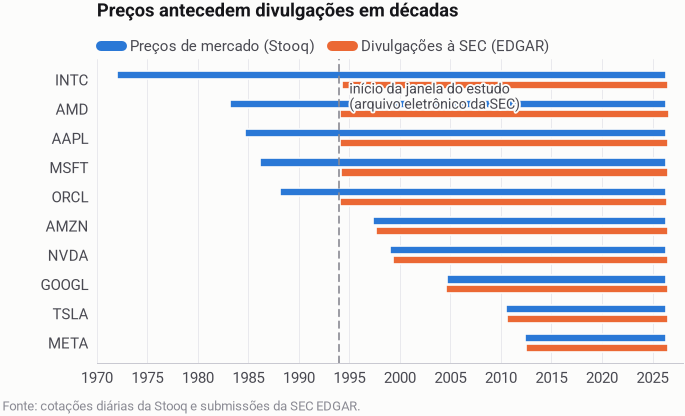

In [11]:
# Figure: data availability by source

fig, ax = plt.subplots(figsize=(6.30, 3.29))

order = coverage_df.sort_values("market_start", ascending=False).index.tolist()
market_color, filings_color = viz.CATEGORICAL[0], viz.CATEGORICAL[1]

for position, ticker in enumerate(order):
    row = coverage_df.loc[ticker]
    for offset, (start, end, color) in enumerate([
        (row["market_start"], row["market_end"], market_color),
        (row["filings_start"], row["filings_end"], filings_color),
    ]):
        left = mdates.date2num(start)
        ax.barh(
            position + (0.17 if offset == 0 else -0.17),
            mdates.date2num(end) - left,
            left=left, height=0.28, color=color,
            edgecolor=viz.SURFACE, linewidth=1.0,
        )

study_start = mdates.date2num(pd.Timestamp("1994-01-01"))
ax.axvline(study_start, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate(
    "início da janela do estudo\n(arquivo eletrônico da SEC)",
    xy=(study_start, len(order) - 1.6),
    xytext=(6, 0), textcoords="offset points", fontsize=8.5,
    color=viz.INK_SECONDARY, va="center",
)

ax.set_yticks(range(len(order)), order)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(mdates.date2num(pd.Timestamp("1970-01-01")),
            mdates.date2num(pd.Timestamp("2028-01-01")))
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
ax.set_ylim(-0.7, len(order) - 0.3)

for spine in ("left",):
    ax.spines[spine].set_visible(False)

handles = [
    plt.Line2D([], [], color=market_color, linewidth=6, label="Preços de mercado (Stooq)"),
    plt.Line2D([], [], color=filings_color, linewidth=6, label="Divulgações à SEC (EDGAR)"),
]
viz.legend_above(ax, handles=handles, ncols=2)
viz.hide_axis_ticks(ax)

viz.title(ax, "Preços antecedem divulgações em décadas", legend_rows=1)
viz.source_note(fig, "Fonte: cotações diárias da Stooq e submissões da SEC EDGAR.")

viz.save_fig(fig, "01_data_availability")
plt.show()

---

## 4. Cleaning the market layer

Three decisions are applied, in this order.

**The window closes on the last date common to all sources.** Prices were collected up to
21 May 2026 while filings run to August 2026, so anything after the market cut-off would
produce a period with disclosures but no price reaction: a spurious asymmetry at the very
end of the sample. The window closes at the earlier boundary.

**The window opens in 1994, and the 2015 floor is dropped.** Two independent pieces of
evidence converge on the same boundary. EDGAR's electronic archive begins in 1994, so no
disclosure signal exists before it. And the quantisation diagnostic shows that pre-1990
quotes move on a price grid coarse enough to manufacture 50–100% returns out of a single
tick. Opening in 1994 keeps every observation for which both layers are meaningful and
discards only the era where the price series cannot support return-based features. That
is roughly two and a half times the history the 2015 floor allowed, and it includes the
dot-com collapse, the 2008 crisis, the COVID shock and the 2022 drawdown.

**Zero volumes become missing values and are interpolated,** as diagnosed above.

In [12]:
# Applying the market cleaning rules

WINDOW_START = pd.Timestamp("1994-01-01")
WINDOW_END = market_raw_df["date"].max()

clean_market_df = market_raw_df[
    market_raw_df["date"].between(WINDOW_START, WINDOW_END)
].copy()
clean_market_df["ticker"] = clean_market_df["ticker"].str.upper().str.strip()

clean_market_df["volume_imputed"] = clean_market_df["volume"] <= 0
clean_market_df.loc[clean_market_df["volume_imputed"], "volume"] = np.nan
clean_market_df["volume"] = (
    clean_market_df.groupby("ticker")["volume"].transform(lambda series: series.interpolate(limit_direction="both"))
)

clean_market_df = (
    clean_market_df.drop_duplicates(["ticker", "date"]).sort_values(["ticker", "date"]).reset_index(drop=True)
)

retained = len(clean_market_df) / len(market_raw_df)
print(f"Study window: {WINDOW_START.date()} to {WINDOW_END.date()}")
print(f"Rows: {len(clean_market_df):,} ({retained:.1%} of the raw feed)")
print(f"Imputed volumes: {int(clean_market_df['volume_imputed'].sum())}")
print(f"Degenerate OHLC rows remaining: {int(clean_market_df['ohlc_degenerate'].sum())}")

clean_market_df.groupby("ticker").agg(
    rows=("date", "count"),
    start=("date", "min"),
    end=("date", "max"),
    imputed_volumes=("volume_imputed", "sum"),
).reindex(UNIVERSE)

Study window: 1994-01-01 to 2026-05-21
Rows: 67,912 (82.8% of the raw feed)
Imputed volumes: 8
Degenerate OHLC rows remaining: 1


,rows,start,end,imputed_volumes
ticker,,,,
AAPL,8150,1994-01-03,2026-05-21,0
MSFT,8149,1994-01-03,2026-05-21,1
NVDA,6874,1999-01-22,2026-05-21,1
GOOGL,5474,2004-08-19,2026-05-21,1
AMZN,7294,1997-05-16,2026-05-21,1
META,3522,2012-05-18,2026-05-21,0
TSLA,3999,2010-06-28,2026-05-21,1
AMD,8150,1994-01-03,2026-05-21,1
INTC,8150,1994-01-03,2026-05-21,1


In [13]:
# Company metadata

clean_companies_df = companies_raw_df.copy()
clean_companies_df["ticker"] = clean_companies_df["ticker"].str.upper().str.strip()
clean_companies_df["cik"] = clean_companies_df["cik"].astype(str).str.zfill(10)
clean_companies_df["company_name"] = clean_companies_df["company_name"].str.strip()

clean_companies_df = (
    clean_companies_df.drop_duplicates(["ticker", "cik"]).sort_values("ticker").reset_index(drop=True)
)

clean_companies_df

,ticker,cik,company_name,source,collected_at
0,AAPL,0000320193,Apple Inc.,sec_edgar,2026-08-07 09:03:36.857479+00:00
1,AMD,0000002488,ADVANCED MICRO DEVICES INC,sec_edgar,2026-08-07 09:03:36.862410+00:00
2,AMZN,0001018724,AMAZON COM INC,sec_edgar,2026-08-07 09:03:36.857482+00:00
3,GOOGL,0001652044,Alphabet Inc.,sec_edgar,2026-08-07 09:03:36.857480+00:00
4,INTC,0000050863,INTEL CORP,sec_edgar,2026-08-07 09:03:36.857488+00:00
5,META,0001326801,"Meta Platforms, Inc.",sec_edgar,2026-08-07 09:03:36.857483+00:00
6,MSFT,0000789019,MICROSOFT CORP,sec_edgar,2026-08-07 09:03:36.857481+00:00
7,NVDA,0001045810,NVIDIA CORP,sec_edgar,2026-08-07 09:03:36.857475+00:00
8,ORCL,0001341439,ORACLE CORP,sec_edgar,2026-08-07 09:03:36.857500+00:00
9,TSLA,0001318605,"Tesla, Inc.",sec_edgar,2026-08-07 09:03:36.857484+00:00


---

## 5. Cleaning the disclosure layer

Three form families carry the disclosure signal this project uses:

| Family | Content | Timing |
|---|---|---|
| **10-K** | annual report | once a year, scheduled |
| **10-Q** | quarterly report | three times a year, scheduled |
| **8-K** | current report on a material event | unscheduled: this is the informative one |

Two details decide whether a thirty-year series is comparable to itself. First, form
*names* changed: annual reports filed between 1996 and 2002 often carry the label
**10-K405**, a variant that certified compliance with Rule 405 disclosure. Treating it as
a different form would show annual reporting mysteriously vanishing for six years.
Second, **amendments** (`10-K/A`, `8-K/A`) restate an earlier filing. They are genuine
disclosure events and are kept, but flagged, so that later stages can count original
filings and revisions separately rather than double-counting a single underlying event.

In [14]:
# Normalising forms, families and amendment status

def split_form(form_type: str) -> tuple[str | None, bool]:
    """Map a raw EDGAR form label onto (family, is_amendment)."""
    is_amendment = form_type.endswith("/A")
    base = form_type[:-2] if is_amendment else form_type
    return FORM_FAMILY.get(base), is_amendment


clean_filings_df = filings_raw_df.copy()
clean_filings_df["ticker"] = clean_filings_df["ticker"].str.upper().str.strip()
clean_filings_df["form_type"] = clean_filings_df["form_type"].str.upper().str.strip()

parsed_forms = clean_filings_df["form_type"].map(split_form)
clean_filings_df["form_family"] = [family for family, _ in parsed_forms]
clean_filings_df["is_amendment"] = [amended for _, amended in parsed_forms]

clean_filings_df = clean_filings_df[clean_filings_df["form_family"].notna()].copy()
clean_filings_df = clean_filings_df[clean_filings_df["filing_date"] <= WINDOW_END]

clean_filings_df["cik"] = clean_filings_df["cik"].astype(str).str.zfill(10)
clean_filings_df["reporting_lag_days"] = (
    clean_filings_df["filing_date"] - clean_filings_df["report_date"]
).dt.days

clean_filings_df = (
    clean_filings_df.drop_duplicates(["ticker", "accession_number"]).sort_values(["ticker", "filing_date"]).reset_index(drop=True)
)

print(f"Disclosure records retained: {len(clean_filings_df):,}")
print(f"Amendments: {int(clean_filings_df['is_amendment'].sum())}")

pd.crosstab(clean_filings_df["ticker"], clean_filings_df["form_family"]).reindex(UNIVERSE)

Disclosure records retained: 3,941
Amendments: 135


form_family,10-K,10-Q,8-K
ticker,,,
AAPL,34,99,234
MSFT,32,104,283
NVDA,31,84,242
GOOGL,25,68,252
AMZN,31,87,267
META,16,42,136
TSLA,22,48,245
AMD,47,106,446
INTC,34,97,450


In [15]:
# Reporting lag by form family (periodic reports only)

# Amendments are excluded here: a 10-K/A filed years later restates an old period and
# would describe the revision process rather than the original reporting deadline.
periodic_df = clean_filings_df[
    clean_filings_df["form_family"].isin(["10-K", "10-Q"])
    & clean_filings_df["reporting_lag_days"].notna()
    & (~clean_filings_df["is_amendment"])
]

lag_summary_df = periodic_df.groupby("form_family")["reporting_lag_days"].agg(
    filings="size", median_days="median", p90_days=lambda s: s.quantile(0.90),
    min_days="min", max_days="max",
    negative_lags=lambda s: int((s < 0).sum()),
)

lag_summary_df

,filings,median_days,p90_days,min_days,max_days,negative_lags
form_family,,,,,,
10-K,271,41.0000,86.0000,0,107,0
10-Q,811,30.0000,45.0000,0,197,0


The reporting lag: days between the period being reported and the filing reaching EDGAR,
behaves as regulation dictates. Quarterly reports cluster at a median of about a month and
annual reports at roughly a month and a half, inside the 40- and 60-day deadlines that
apply to large accelerated filers. No negative lags appear, confirming that no filing
claims to report a period that had not yet ended.

This lag is not a curiosity. It is the reason the feature stage must key filing activity
to the **filing date** rather than the period end: a market can only react to information
on the day it becomes public, and using the period end would leak roughly a month of
hindsight into every observation.

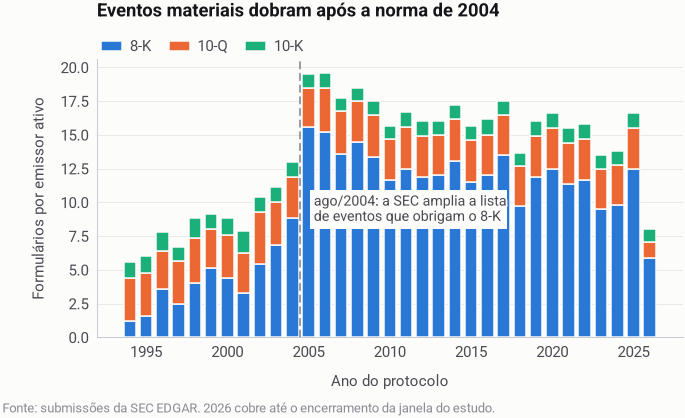

In [16]:
# Figure: disclosure activity over three decades

# Counts alone would confound the rule change with the panel filling up: only four
# issuers were listed in 1994 and ten by 2012. Normalising per active issuer isolates
# the change in filing behaviour from the change in the panel.
filings_by_year = clean_filings_df.assign(year=clean_filings_df["filing_date"].dt.year)
active_issuers = filings_by_year.groupby("year")["ticker"].nunique()

annual_filings = (
    filings_by_year.groupby(["year", "form_family"]).size().unstack(fill_value=0).reindex(columns=["8-K", "10-Q", "10-K"], fill_value=0).div(active_issuers, axis=0)
)

fig, ax = plt.subplots(figsize=(6.30, 3.01))

bottom = np.zeros(len(annual_filings))
for slot, family in enumerate(["8-K", "10-Q", "10-K"]):
    values = annual_filings[family].to_numpy()
    ax.bar(
        annual_filings.index, values, bottom=bottom,
        color=viz.CATEGORICAL[slot], label=family,
        edgecolor=viz.SURFACE, linewidth=0.9, width=0.78,
    )
    bottom += values

ax.axvline(2004.5, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate(
    "ago/2004: a SEC amplia a lista\nde eventos que obrigam o 8-K",
    xy=(2004.5, ax.get_ylim()[1] * 0.46), xytext=(8, 0),
    textcoords="offset points", fontsize=8.5, color=viz.INK_SECONDARY, va="center",
    bbox={"facecolor": viz.SURFACE, "edgecolor": "none", "pad": 2.5},
)

ax.set_xlabel("Ano do protocolo")
ax.set_ylabel("Formulários por emissor ativo")
viz.legend_above(ax, ncols=3)

viz.title(ax, "Eventos materiais dobram após a norma de 2004", legend_rows=1)
viz.source_note(
    fig,
    "Fonte: submissões da SEC EDGAR. 2026 cobre até o encerramento da janela do estudo.",
)

viz.save_fig(fig, "02_filings_by_year")
plt.show()

### A structural break in the disclosure series

Two features of the chart need separating. The ramp through the late 1990s is the EDGAR
phase-in: electronic filing only became mandatory for all domestic registrants in 1996, so
the early years understate true disclosure activity for every form. From 1998 onward the
periodic forms settle at their regulated frequency (three 10-Qs and one 10-K per issuer
per year) and stay there.

Against that flat baseline, the 8-K series steps up in the mid-2000s. The candidate explanation is
regulatory rather than economic: effective **23 August 2004**, the SEC expanded Form 8-K
from roughly a dozen triggering events to more than twenty and shortened the deadline to
four business days. If that is what happened, the level shift is an artefact of the
reporting regime, and a feature such as "8-K filings in the last 90 days" is not
comparable across the break.

This is testable. Filing counts per issuer-quarter are heavily skewed and bounded below
at zero, so a Mann-Whitney U test is used rather than a t-test, with the rank-biserial
correlation as effect size. Two precautions matter: quarters in which an issuer filed
nothing must be counted as zeros rather than dropped, and the comparison is restricted to
issuers observed on both sides of the break, so that a change in the composition of the
panel cannot masquerade as a change in behaviour.

In [17]:
# Testing the 2004 regime change in 8-K frequency

BREAK_DATE = pd.Timestamp("2004-08-23")

eight_k_df = clean_filings_df[
    (clean_filings_df["form_family"] == "8-K") & (~clean_filings_df["is_amendment"])
].copy()
eight_k_df["quarter"] = eight_k_df["filing_date"].dt.to_period("Q")

# A quarter with no 8-K is a zero, not an absence: rebuild the full quarterly grid
# between each issuer's first and last observed filing.
panel_rows = []
for ticker, group in eight_k_df.groupby("ticker"):
    quarters = pd.period_range(group["quarter"].min(), group["quarter"].max(), freq="Q")
    counts = group.groupby("quarter").size().reindex(quarters, fill_value=0)
    panel_rows.append(pd.DataFrame({
        "ticker": ticker, "quarter": quarters, "filings": counts.to_numpy(),
    }))

quarterly_panel_df = pd.concat(panel_rows, ignore_index=True)
quarterly_panel_df["era"] = np.where(
    quarterly_panel_df["quarter"].dt.start_time < BREAK_DATE, "pre-2004", "post-2004"
)

eras_per_ticker = quarterly_panel_df.groupby("ticker")["era"].nunique()
balanced_tickers = eras_per_ticker[eras_per_ticker == 2].index
balanced_panel_df = quarterly_panel_df[quarterly_panel_df["ticker"].isin(balanced_tickers)]

pre = balanced_panel_df.loc[balanced_panel_df["era"] == "pre-2004", "filings"]
post = balanced_panel_df.loc[balanced_panel_df["era"] == "post-2004", "filings"]

test = stats.mannwhitneyu(post, pre, alternative="greater")
rank_biserial = 2 * test.statistic / (len(post) * len(pre)) - 1

print(f"Issuers observed in both eras: {len(balanced_tickers)} ({', '.join(sorted(balanced_tickers))})")
print(f"Pre-2004: {len(pre):>4} issuer-quarters | mean {pre.mean():.2f} | median {pre.median():.1f}")
print(f"Post-2004: {len(post):>4} issuer-quarters | mean {post.mean():.2f} | median {post.median():.1f}")
print(f"\nMann-Whitney U = {test.statistic:,.0f} | p = {test.pvalue:.3e} (one-sided, post > pre)")
print(f"Rank-biserial correlation = {rank_biserial:.3f}")

Issuers observed in both eras: 8 (AAPL, AMD, AMZN, GOOGL, INTC, MSFT, NVDA, ORCL)
Pre-2004:  214 issuer-quarters | mean 1.33 | median 1.0
Post-2004:  696 issuer-quarters | mean 2.97 | median 3.0

Mann-Whitney U = 117,692 | p = 1.373e-39 (one-sided, post > pre)
Rank-biserial correlation = 0.580


In [18]:
# The same comparison, issuer by issuer

per_ticker_break_df = (
    balanced_panel_df.pivot_table(
        index="ticker", columns="era", values="filings", aggfunc="mean"
    )[["pre-2004", "post-2004"]]
)
per_ticker_break_df["change_pct"] = (
    100 * (per_ticker_break_df["post-2004"] / per_ticker_break_df["pre-2004"] - 1)
).round(1)

per_ticker_break_df.sort_values("change_pct", ascending=False)

era,pre-2004,post-2004,change_pct
ticker,,,
MSFT,0.5122,2.9540,476.7000
AAPL,0.7353,2.3793,223.6000
INTC,1.5250,4.3908,187.9000
GOOGL,1.0000,2.8046,180.5000
ORCL,1.0000,2.6092,160.9000
NVDA,1.2353,2.4828,101.0000
AMD,2.0930,3.7816,80.7000
AMZN,2.0000,2.3678,18.4000


The increase is statistically clear and consistent across issuers, but the effect size is
what matters for the pipeline: the shift is a level change in a regulated reporting
requirement, not a change in how eventful these companies became.

**Consequence carried forward.** Any feature counting filings over a window is comparable
*within* a regime and not *across* it. Two mitigations are available, restricting the
modelling window to the post-2004 regime, or normalising counts per issuer against a
trailing baseline so that only deviations from each issuer's own norm carry signal. The
feature stage adopts the second, and the XBRL constraint from Section 1 means the
modelling window begins after 2009 in any case, comfortably inside the post-2004 regime.

---

## 6. Cleaning the fundamentals layer

XBRL company facts arrive as a long table of concept observations, and two properties
require explicit handling.

**Instant versus duration concepts.** A balance-sheet item such as `Assets` is measured
at a point in time and carries only an end date; an income-statement item such as
`NetIncomeLoss` spans a period and carries both a start and an end. The missing start
date on instant concepts is the data model working correctly, not a gap. Both are keyed
on the end date so the two can live in one table.

**Restatements.** The same fiscal period is reported repeatedly: first in the original
filing, then as a comparative figure in later ones, and occasionally revised. Keeping
every version would multiply rows and, worse, would let a value revised in 2020 attach
itself to an observation in 2015. Only the *first* published value for each period is
retained, which is what a market participant could actually have known at the time.

In [19]:
# Normalising and de-restating the XBRL facts

clean_facts_df = facts_raw_df.copy()
clean_facts_df["ticker"] = clean_facts_df["ticker"].str.upper().str.strip()
clean_facts_df["cik"] = clean_facts_df["cik"].astype(str).str.zfill(10)
clean_facts_df["value"] = pd.to_numeric(clean_facts_df["value"], errors="coerce")
clean_facts_df["form_type"] = clean_facts_df["form_type"].str.upper().str.strip()

clean_facts_df["reference_date"] = clean_facts_df["end_date"]
clean_facts_df["period_type"] = np.where(
    clean_facts_df["start_date"].isna(), "instant", "duration"
)

clean_facts_df = clean_facts_df.dropna(subset=["ticker", "concept", "value", "end_date"])
clean_facts_df = clean_facts_df[clean_facts_df["filing_date"] <= WINDOW_END]

period_key = ["ticker", "concept", "unit", "start_date", "end_date"]

# A period is *republished* whenever it reappears as a comparative figure in a later
# filing, which is routine. It is *restated* only when the republished number differs
# from the original: a materially different event, and much rarer.
grouped_periods = clean_facts_df.groupby(period_key, dropna=False)["value"]
clean_facts_df["republication_count"] = grouped_periods.transform("size") - 1
clean_facts_df["distinct_values"] = grouped_periods.transform("nunique")

# Keep the earliest publication of each period: the figure known at the time.
clean_facts_df = (
    clean_facts_df.sort_values(period_key + ["filing_date"]).drop_duplicates(period_key, keep="first").sort_values(["ticker", "concept", "end_date"]).reset_index(drop=True)
)

republished = int((clean_facts_df["republication_count"] > 0).sum())
restated = int((clean_facts_df["distinct_values"] > 1).sum())

print(f"Distinct reporting periods retained: {len(clean_facts_df):,}")
print(f"Republished at least once (routine comparatives): {republished:,}")
print(f"Republished with a changed value (true restatements): {restated:,}")

clean_facts_df.groupby("period_type").agg(
    observations=("value", "size"),
    concepts=("concept", "nunique"),
    first_period=("reference_date", "min"),
    last_period=("reference_date", "max"),
)

Distinct reporting periods retained: 6,526
Republished at least once (routine comparatives): 4,650
Republished with a changed value (true restatements): 331


,observations,concepts,first_period,last_period
period_type,,,,
duration,4138,5,2007-09-29,2026-04-26
instant,2388,4,2006-09-30,2026-04-26


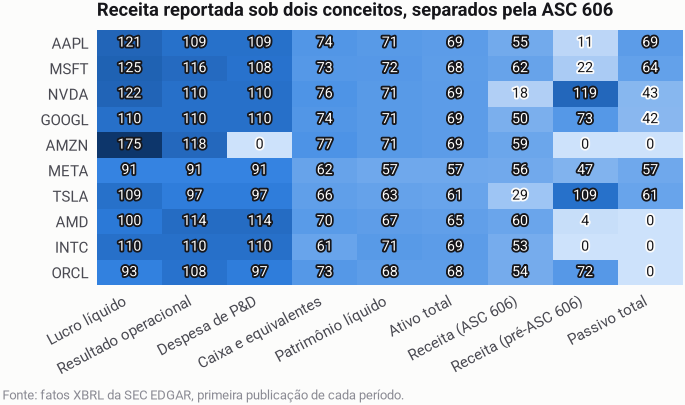

In [20]:
# Figure: fundamentals coverage by issuer and concept

coverage_matrix = (
    clean_facts_df.pivot_table(
        index="ticker", columns="concept", values="value", aggfunc="size", fill_value=0
    ).reindex(UNIVERSE)
)
coverage_matrix = coverage_matrix[coverage_matrix.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(6.30, 2.76))
mesh = ax.imshow(coverage_matrix.to_numpy(), cmap=viz.sequential_cmap(), aspect="auto")

CONCEPT_LABELS = {
    "NetIncomeLoss": "Lucro líquido",
    "OperatingIncomeLoss": "Resultado operacional",
    "ResearchAndDevelopmentExpense": "Despesa de P&D",
    "CashAndCashEquivalentsAtCarryingValue": "Caixa e equivalentes",
    "StockholdersEquity": "Patrimônio líquido",
    "Assets": "Ativo total",
    "Liabilities": "Passivo total",
    "Revenues": "Receita (pré-ASC 606)",
    "RevenueFromContractWithCustomerExcludingAssessedTax": "Receita (ASC 606)",
}

ax.set_xticks(
    range(coverage_matrix.shape[1]),
    [CONCEPT_LABELS.get(column, column) for column in coverage_matrix.columns],
    rotation=28, ha="right",
)
ax.set_yticks(range(len(coverage_matrix)), coverage_matrix.index)
ax.grid(visible=False)
for spine in ax.spines.values():
    spine.set_visible(False)
viz.hide_axis_ticks(ax, "both")

threshold = coverage_matrix.to_numpy().max() * 0.55
for row in range(coverage_matrix.shape[0]):
    for column in range(coverage_matrix.shape[1]):
        value = coverage_matrix.iat[row, column]
        ax.text(
            column, row, f"{value:.0f}", ha="center", va="center", fontsize=8.5,
            color=viz.ink_on(mesh.cmap(mesh.norm(value))),
        )

viz.title(ax, "Receita reportada sob dois conceitos, separados pela ASC 606")
viz.source_note(fig, "Fonte: fatos XBRL da SEC EDGAR, primeira publicação de cada período.")

viz.save_fig(fig, "03_fundamentals_coverage")
plt.show()

The coverage matrix exposes three taxonomy problems that would otherwise surface as
unexplained missing data much later.

**Revenue is split across two concepts.** Older periods are tagged `Revenues`; from the
2018 adoption of ASC 606 the tag becomes
`RevenueFromContractWithCustomerExcludingAssessedTax`. No issuer uses both consistently,
so the feature stage has to coalesce them into one series: otherwise every company shows
a revenue gap on one side of 2018.

**Total liabilities are frequently absent,** because many filers disclose only total
liabilities and shareholders' equity together, from which liabilities must be derived
rather than read directly.

**Amazon reports no R&D expense at all** under the standard concept: it discloses
"technology and content" instead, a broader line item that is not tagged
`ResearchAndDevelopmentExpense`. This is a genuine reporting-policy difference, not a
collection failure, and it means any R&D-derived feature is structurally missing for one
issuer rather than missing at random.

---

## 7. Cross-source consistency

The market layer and the disclosure layer are joined on a date, so the two calendars have
to be reconciled explicitly. EDGAR accepts filings on any business day, while the market
series only contains exchange sessions: the two differ on exchange holidays that are not
federal holidays, and on filings submitted after the close.

The rule established here is that a filing is attached to the **next available trading
session**. The distribution below shows how often that shift is needed and how large it
is.

In [21]:
# Reconciling filing dates against the trading calendar

trading_days = pd.DatetimeIndex(sorted(clean_market_df["date"].unique()))

filing_dates = pd.DatetimeIndex(clean_filings_df["filing_date"])
next_session_position = trading_days.searchsorted(filing_dates, side="left")

within_range = next_session_position < len(trading_days)
next_session = pd.Series(pd.NaT, index=clean_filings_df.index, dtype="datetime64[ns]")
next_session.loc[within_range] = trading_days[next_session_position[within_range]]

clean_filings_df["next_trading_session"] = next_session.to_numpy()
clean_filings_df["days_to_session"] = (
    clean_filings_df["next_trading_session"] - clean_filings_df["filing_date"]
).dt.days

alignment_df = (
    clean_filings_df["days_to_session"].value_counts(dropna=False).sort_index().rename("filings").to_frame()
)
alignment_df["share_pct"] = (100 * alignment_df["filings"] / len(clean_filings_df)).round(2)
alignment_df.index.name = "days until next trading session"

alignment_df.head(8)

,filings,share_pct
days until next trading session,,
0,3925,99.5900
1,1,0.0300
2,1,0.0300
3,14,0.3600


Most filings land on a trading day and need no shift; the remainder are weekend and
holiday submissions that map forward by one to three days. Nothing is orphaned, which
confirms the two calendars are compatible once the forward-shift rule is applied.

---

## 8. Data quality scorecard, before and after

Scoring only the cleaned data would be self-congratulatory: every dimension would read
100% and the number would carry no information. The scorecard is therefore computed twice
by the *same function*, once on the previous pipeline and once on this one, so the
comparison measures the change rather than the author's opinion of it.

The previous pipeline is reconstructed from the same raw files by re-applying its rules:
a 2015 floor, filings from the current CIK only, exact form labels with no historical
variants, and no de-restatement of the XBRL layer.

| Dimension | Rule |
|---|---|
| Field completeness | required fields populated across the three layers |
| Record uniqueness | one row per natural key (ticker-date, ticker-accession, reporting period) |
| Domain validity | OHLC ordering, positive prices, positive volume |
| Calendar consistency | filings resolvable to a trading session within five days |
| Lineage coverage | issuers whose full sequence of legal entities is represented |
| Temporal coverage | market observations retained within the 1994 study window |

In [22]:
# Reconstructing the previous pipeline from the same raw files

LEGACY_START = pd.Timestamp("2015-01-01")
LEGACY_FORMS = ["10-K", "10-Q", "8-K"]

predecessor_ciks = set(lineage_df.loc[lineage_df["is_predecessor"], "cik"])

legacy_market_df = market_raw_df[market_raw_df["date"].between(LEGACY_START, WINDOW_END)]
legacy_filings_df = filings_raw_df[
    (~filings_raw_df["cik"].isin(predecessor_ciks))
    & (filings_raw_df["form_type"].isin(LEGACY_FORMS))
    & (filings_raw_df["filing_date"].between(LEGACY_START, WINDOW_END))
]
legacy_facts_df = facts_raw_df[
    (~facts_raw_df["cik"].isin(predecessor_ciks))
    & (facts_raw_df["filing_date"] <= WINDOW_END)
]

entities_expected = lineage_df.groupby("ticker")["cik"].nunique().reindex(UNIVERSE)
window_available = len(market_raw_df[market_raw_df["date"].between(WINDOW_START, WINDOW_END)])

REQUIRED_MARKET = ["ticker", "date", "open", "high", "low", "close", "volume"]
REQUIRED_FILINGS = ["ticker", "accession_number", "filing_date", "form_type"]
REQUIRED_FACTS = ["ticker", "concept", "value", "end_date"]


def score_pipeline(market, filings, facts) -> dict[str, float]:
    """Score one pipeline's output on the six dimensions, all as shares in [0, 1]."""
    frames = [
        (market, REQUIRED_MARKET, ["ticker", "date"]),
        (filings, REQUIRED_FILINGS, ["ticker", "accession_number"]),
        (facts, REQUIRED_FACTS, period_key),
    ]

    missing_cells = sum(frame[columns].isna().to_numpy().sum() for frame, columns, _ in frames)
    total_cells = sum(frame[columns].size for frame, columns, _ in frames)
    duplicates = sum(frame.duplicated(key).sum() for frame, _, key in frames)
    total_rows = sum(len(frame) for frame, _, _ in frames)

    validity = (
        (market["high"] >= market["low"])
        & (market["close"] > 0)
        & (market["volume"] > 0)
    ).mean()

    sessions = pd.DatetimeIndex(sorted(market["date"].unique()))
    filing_dates = pd.DatetimeIndex(filings["filing_date"])
    positions = sessions.searchsorted(filing_dates, side="left")
    resolvable = positions < len(sessions)
    shift_days = np.full(len(filings), np.inf)
    shift_days[resolvable] = (
        sessions[positions[resolvable]] - filing_dates[resolvable]
    ).days
    consistency = float((shift_days <= 5).mean())

    entities_present = filings.groupby("ticker")["cik"].nunique().reindex(UNIVERSE).fillna(0)
    lineage = float((entities_present >= entities_expected).mean())

    retained = len(market[market["date"] >= WINDOW_START])

    return {
        "field completeness": 1 - missing_cells / total_cells,
        "record uniqueness": 1 - duplicates / total_rows,
        "domain validity": float(validity),
        "calendar consistency": consistency,
        "lineage coverage": lineage,
        "temporal coverage": retained / window_available,
    }


scorecard_df = pd.DataFrame({
    "previous pipeline": score_pipeline(legacy_market_df, legacy_filings_df, legacy_facts_df),
    "current pipeline": score_pipeline(clean_market_df, clean_filings_df, clean_facts_df),
})
scorecard_df["change_pp"] = (
    100 * (scorecard_df["current pipeline"] - scorecard_df["previous pipeline"])
).round(1)

(scorecard_df[["previous pipeline", "current pipeline"]] * 100).round(2).join(
    scorecard_df[["change_pp"]]
)

,previous pipeline,current pipeline,change_pp
field completeness,100.0000,100.0000,0.0000
record uniqueness,81.2100,100.0000,18.8000
domain validity,100.0000,100.0000,0.0000
calendar consistency,100.0000,100.0000,0.0000
lineage coverage,80.0000,100.0000,20.0000
temporal coverage,42.1600,100.0000,57.8000


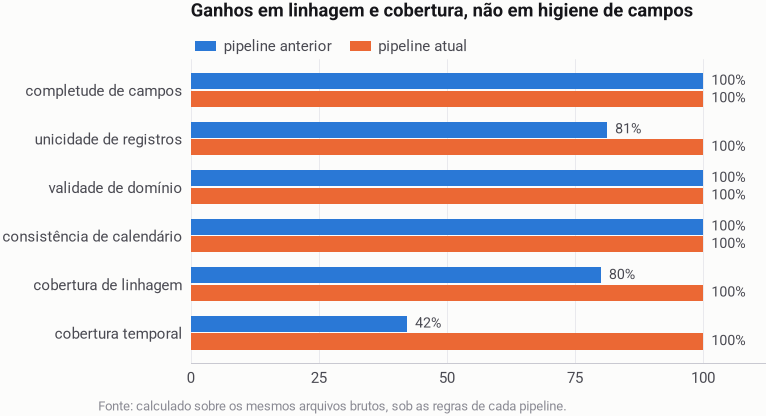

In [23]:
# Figure: quality scorecard, previous versus current pipeline

scores = (scorecard_df[["previous pipeline", "current pipeline"]] * 100).round(2)
scores.columns = ["pipeline anterior", "pipeline atual"]
scores.index = [
    "completude de campos", "unicidade de registros", "validade de domínio",
    "consistência de calendário", "cobertura de linhagem", "cobertura temporal",
]
positions = np.arange(len(scores))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(6.17, 3.29))

for slot, column in enumerate(scores.columns):
    offset = bar_height / 2 * (1 if slot == 1 else -1)
    ax.barh(
        positions + offset, scores[column], height=bar_height - 0.03,
        color=viz.CATEGORICAL[slot], label=column,
    )
    for position, value in zip(positions, scores[column]):
        ax.annotate(
            f"{value:.0f}%", xy=(value, position + offset), xytext=(5, 0),
            textcoords="offset points", va="center", fontsize=8.5,
            color=viz.INK_SECONDARY,
        )

ax.set_yticks(positions, scores.index)
ax.invert_yaxis()
ax.set_xlim(0, 112)
ax.set_xticks([0, 25, 50, 75, 100])
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
viz.legend_above(ax, ncols=2)
viz.hide_axis_ticks(ax)

viz.title(ax, "Ganhos em linhagem e cobertura, não em higiene de campos", legend_rows=1)
viz.source_note(fig, "Fonte: calculado sobre os mesmos arquivos brutos, sob as regras de cada pipeline.")

viz.save_fig(fig, "04_quality_scorecard")
plt.show()

In [24]:
# Persisting the analytical base

clean_market_df.to_csv(DATA_DIR / "clean_market_data.csv", index=False)
clean_companies_df.to_csv(DATA_DIR / "clean_company_metadata.csv", index=False)
clean_filings_df.to_csv(DATA_DIR / "clean_sec_filings.csv", index=False)
clean_facts_df.to_csv(DATA_DIR / "clean_sec_facts.csv", index=False)

quality_report_df = scorecard_df.reset_index(names="dimension")
quality_report_df["study_window_start"] = WINDOW_START.date()
quality_report_df["study_window_end"] = WINDOW_END.date()
quality_report_df.to_csv(DATA_DIR / "data_quality_report.csv", index=False)

for name, frame in {
    "clean_market_data": clean_market_df,
    "clean_company_metadata": clean_companies_df,
    "clean_sec_filings": clean_filings_df,
    "clean_sec_facts": clean_facts_df,
}.items():
    print(f"{name:<26} {frame.shape[0]:>7,} rows x {frame.shape[1]:>2} columns")

clean_market_data           67,912 rows x 11 columns
clean_company_metadata          10 rows x  5 columns
clean_sec_filings            3,941 rows x 15 columns
clean_sec_facts              6,526 rows x 21 columns


---

## Conclusion

The analytical base is validated and materially larger than the one the first version of
this pipeline produced.

| | Previous version | This version |
|---|---|---|
| Study window | 2015-01-01 onward | 1994-01-01 to the common cut-off |
| Market observations | 28,630 | see the summary printed above |
| Disclosure records | 1,092 core filings | full EDGAR history, lineage-resolved |
| Market regimes covered | one (post-2015 expansion) | dot-com, 2008, COVID, 2022 |
| Quality assessment | narrative | six dimensions, scored against the previous pipeline |

Five findings constrain everything downstream and are carried forward explicitly:

1. **Lineage must be resolved by entity, not ticker.** Two of ten issuers lose a decade
   of history otherwise. Any extension of the universe has to repeat this check.
2. **The volume field carries a vendor artefact on 2010-04-26.** Prices are sound;
   affected volumes are interpolated and flagged.
3. **The 8-K series has a regulatory break in August 2004.** Filing-count features are
   comparable within a regime, not across it, and must be normalised per issuer.
4. **Revenue is split across two XBRL concepts by the ASC 606 transition,** and has to be
   coalesced rather than treated as two columns.
5. **Pre-1990 quotes are quantised** by cumulative split adjustment, which is what fixes
   the study window at 1994 rather than at the earliest available price.

The market series is split-adjusted, gap-free and arithmetically consistent, and the
largest moves in it correspond to documented economic events rather than corporate-action
artefacts: which is what makes them usable as a face-validity check on the anomaly model
later.

The next notebook characterises this base statistically: distributional properties,
stationarity, autocorrelation, volatility clustering and the market's measured reaction
to disclosure events.